# Split Notebook 2 — Modeling and Link Prediction

This notebook contains the split construction, tabular baselines, pair-level modeling, and graph-related training material.

In [ ]:
from notebook_helpers import (
    as_list,
    normalize_scalar,
    extract_author_names,
    extract_strings,
    safe_int,
    tokenize_text,
    jaccard,
    get_edge_index,
    subsample_edges,
    sample_negatives_hard,
    pairs_to_matrix,
    create_pair_df_from_edges,
    build_pair_features,
)


**Change:** Kept `n_references` and `years_since_publication` available for modeling, while explicitly dropping venue-prestige leakage features.
**Why:** Outgoing references and publication age are known at publication time, but global venue prestige flags should not leak future information into training.

In [3]:
leaky_features = [
    "citation_per_year",
    "impact_score",
    "citation_richness",
    "is_highly_cited_for_year",
    "avg_author_citations",
    "max_author_citations",
    "venue_median_citations",
    "references_author_ratio",
    "has_high_ref_count",
    "is_top_venue",
    "venue_tier",
]

## SPLIT

Inspect the feature file used to build the temporal train/val/test split.

In [ ]:
import pyarrow.parquet as pq
import pandas as pd

INPUT_FILE = "papers_with_features_with_refs.parquet"

# Read schema without loading data
pf = pq.read_schema(INPUT_FILE)
print(f"Total columns: {len(pf.names)}\n")
print(f"{'Column':<45} {'Type':<20}")
print("-" * 65)
for name in pf.names:
    print(f"{name:<45} {str(pf.field(name).type):<20}")

# Load only first 3 rows to see actual values
print("\n--- Sample values (3 rows) ---")
sample = pd.read_parquet(INPUT_FILE).head(3)
for col in sample.columns:
    print(f"\n{col}: {sample[col].tolist()}")

In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                        CONFIGURATION                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
INPUT_FILE = "papers_with_features_with_refs.parquet"  # ← file con references
OUTPUT_DIR = "model_splits"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Check if split files already exist
split_files_exist = all([
    os.path.exists(f"{OUTPUT_DIR}/train.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/val.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/test.parquet")
])

if split_files_exist:
    print(f"Split files already exist in '{OUTPUT_DIR}'. Skipping creation.")
else:
    print("Loading dataset...")
    df = pd.read_parquet(INPUT_FILE)

    # ── 1. Temporal sorting ───────────────────────────────────────────────
    df = df.dropna(subset=["year"]).copy()
    df = df.sort_values("year").reset_index(drop=True)

    # Sequential node_idx 0..N-1 (required by PyTorch Geometric)
    df["node_idx"] = np.arange(len(df), dtype=np.int32)

    # ── 2. Feature definition (NO TARGET NODE FEATURE PER LA LINK PREDICTION)
    
    # Lista di feature da ignorare (leaky_features va definita prima, es. leaky_features = [])
    leaky_features = getattr(globals(), 'leaky_features', []) 

    # Colonne strutturali che NON devono essere usate come feature numeriche (non vanno scalate)
    non_feature_cols = [
        "id",
        "n_citation",
        "node_idx",
        "split",
        "year",
        "title",
        "abstract",
        "venue",
        "publication_era",
        "venue_tier",
        "references",       # ← FONDAMENTALE: contiene i link (edge_index)
        "target_variable"   # Lo includiamo qui solo per evitare che venga scalato se fosse rimasto nel dataframe per sbaglio
    ]

    exclude_cols = set(non_feature_cols + list(leaky_features))

    # Seleziona solo le colonne numeriche valide
    safe_numeric_features = [
        col for col in df.columns
        if col not in exclude_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    print(f"\nSafe numeric features selected ({len(safe_numeric_features)}):")
    for f in safe_numeric_features[:5]:
        print(f"  ✓  {f}")
    if len(safe_numeric_features) > 5:
        print("  ... e altre")

    # ── 3. Temporal splitting (Train <= 2020, Val 2021-2022, Test >= 2023) ───────────────
    df["split"] = ""
    
    df.loc[df["year"] <= 2020, "split"] = "train"
    df.loc[(df["year"] >= 2021) & (df["year"] <= 2022), "split"] = "val"
    df.loc[df["year"] >= 2023, "split"] = "test"

    print("\nSplit distribution:")
    print(df["split"].value_counts().reindex(["train", "val", "test"]))
    print(f"  Train years : {df.loc[df['split']=='train', 'year'].min()} – "
          f"{df.loc[df['split']=='train', 'year'].max()}")
    print(f"  Val years   : {df.loc[df['split']=='val',   'year'].min()} – "
          f"{df.loc[df['split']=='val',   'year'].max()}")
    print(f"  Test years  : {df.loc[df['split']=='test',  'year'].min()} – "
          f"{df.loc[df['split']=='test',  'year'].max()}")

    # ── 4. Strict scaling (fit ONLY on train, transform val/test) ────────
    X_train = df.loc[df["split"] == "train", safe_numeric_features].to_numpy()
    X_val   = df.loc[df["split"] == "val",   safe_numeric_features].to_numpy()
    X_test  = df.loc[df["split"] == "test",  safe_numeric_features].to_numpy()

    X_train = np.nan_to_num(X_train, nan=-999.0, posinf=0.0, neginf=0.0)
    X_val   = np.nan_to_num(X_val,   nan=-999.0, posinf=0.0, neginf=0.0)
    X_test  = np.nan_to_num(X_test,  nan=-999.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    # Cast a float64 per sicurezza e assegnazione
    for col in safe_numeric_features:
        df[col] = df[col].astype("float64")

    df.loc[df["split"] == "train", safe_numeric_features] = X_train_scaled
    df.loc[df["split"] == "val",   safe_numeric_features] = X_val_scaled
    df.loc[df["split"] == "test",  safe_numeric_features] = X_test_scaled

    # ── 5. Save files ─────────────────────────────────────────────────────
    
    # Colonne da mantenere nel file salvato (features + struttura + link)
    keep_cols = safe_numeric_features + [
        "id",
        "node_idx",
        "split",
        "year",
        "references",       # ← vitale per costruire gli edge_index (archi) successivamente
    ]

    # Sicurezza extra: rimuove eventuali colonne duplicate mantenendo l'ordine
    keep_cols = list(dict.fromkeys(keep_cols))

    print("\nSaving split files...")
    df.loc[df["split"] == "train", keep_cols].to_parquet(
        f"{OUTPUT_DIR}/train.parquet", index=False)
    df.loc[df["split"] == "val",   keep_cols].to_parquet(
        f"{OUTPUT_DIR}/val.parquet",   index=False)
    df.loc[df["split"] == "test",  keep_cols].to_parquet(
        f"{OUTPUT_DIR}/test.parquet",  index=False)

    np.save(f"{OUTPUT_DIR}/scaler_mean.npy",  scaler.mean_)
    np.save(f"{OUTPUT_DIR}/scaler_scale.npy", scaler.scale_)

    print(f"\n✓ Done. Files saved in '{OUTPUT_DIR}/'")
    print(f"   Node Features        : {len(safe_numeric_features)}")
    print(f"   Structural columns   : id, node_idx, split, year")
    print(f"   Graph Edges column   : references")
    print(f"   Scaler saved         : scaler_mean.npy, scaler_scale.npy")

Split files already exist in 'model_splits'. Skipping creation.


**Change:** Replaced `nan=0.0` with `nan=-999.0`.
**Why:** If we fill missing dates (like `years_since_publication`) with `0`, the model assumes the paper was published today. By using `-999`, the Decision Trees can immediately create an isolated split rule (e.g., `< -500`) to mathematically separate missing data from true zeros.

In [ ]:
# import pyarrow.parquet as pq

# # Reread LOAD_COLS from the current schema of the new Parquet files
# pf_new = pq.read_schema(f"{OUTPUT_DIR}/train.parquet")
# LOAD_COLS = [c for c in pf_new.names if c not in {"split"}]

# print("LOAD_COLS updated:", LOAD_COLS)

# train_df = load_and_sample(f"{OUTPUT_DIR}/train.parquet", TRAIN_SAMPLE, LOAD_COLS)
# val_df   = load_and_sample(f"{OUTPUT_DIR}/val.parquet",   VAL_SAMPLE,   LOAD_COLS)
# test_df  = load_and_sample(f"{OUTPUT_DIR}/test.parquet",  TEST_SAMPLE,  LOAD_COLS)

# train_df

# CELLA DA ESEGUIRE PER CARICARE GLI SPLIT

In [5]:
import polars as pl

# Carica i file parquet come DataFrame Polars
train_df = pl.read_parquet('model_splits/train.parquet')
val_df = pl.read_parquet('model_splits/val.parquet')
test_df = pl.read_parquet('model_splits/test.parquet')

train_df

title_word_count,abstract_word_count,title_abstract_ratio,title_complexity,abstract_complexity,has_numbers_in_title,has_numbers_in_abstract,n_authors,avg_author_citations,max_author_citations,multi_authored,n_references,references_author_ratio,citation_richness,has_high_ref_count,years_since_publication,decade,is_recent,citation_per_year,is_highly_cited_for_year,impact_score,venue_median_citations,venue_volume,is_top_venue,is_english,id,node_idx,split,year,references
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32,str,i64,list[str]
1.889193,0.966761,-0.097798,-1.158418,-0.017696,0.0,0.0,0.343616,-0.205446,-0.188856,0.422509,-0.805261,-0.650567,-0.602605,-0.092262,181.828368,-181.828368,-0.4163,-0.095382,-1.021094,-0.094982,-0.360159,-0.228457,-0.003601,-5.189611,"""60376557d3485cfff1d91b49""",0,"""train""",0,[]
-1.307626,-0.161032,-0.35108,0.991659,0.282907,0.0,0.0,-0.457601,-0.211314,-0.196218,0.422509,-0.805261,-0.650567,-0.602605,-0.092262,181.828368,-181.828368,-0.4163,-0.095295,0.979342,-0.094958,-0.360159,-0.228457,-0.003601,-5.189611,"""5e54f1813a55acae32a25d83""",1,"""train""",0,[]
-0.508422,0.041717,-0.206753,0.280939,0.152899,0.0,0.0,0.744225,-0.272097,-0.197655,0.422509,-0.805261,-0.650567,-0.602605,-0.092262,181.828368,-181.828368,-0.4163,-0.095394,-1.021094,-0.094985,-0.360159,-0.228457,-0.003601,-5.189611,"""5e4d083f3a55ac8cfd770a60""",2,"""train""",0,[]
-1.041225,-0.541187,-0.356683,-1.715845,0.300257,0.0,0.0,0.744225,-0.257661,-0.195859,0.422509,-0.805261,-0.650567,-0.602605,-0.092262,181.828368,-181.828368,-0.4163,-0.095382,-1.021094,-0.094982,0.483989,-0.232516,-0.003601,-5.189611,"""5e79da3b91e0115bb11579c1""",3,"""train""",0,[]
-1.041225,0.561262,-0.436269,0.450158,0.232997,0.0,0.0,1.545442,0.400041,6.527496,0.422509,-0.805261,-0.650567,-0.602605,-0.092262,181.828368,-181.828368,-0.4163,-0.093368,0.979342,-0.094432,0.192374,-0.23262,-0.003601,-5.189611,"""5dce788a3a55ac9580a16242""",4,"""train""",0,[]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.024382,0.599278,-0.26556,-0.307943,0.104951,0.0,0.0,-0.457601,-0.198442,-0.186701,0.422509,-0.633791,-0.46822,-0.508719,-0.092262,-0.89694,0.89694,2.402113,-0.070286,-1.021094,-0.071551,-0.26807,-0.231839,-0.003601,0.192693,"""5ea0135c9fced0a24b9d88e4""",4087964,"""train""",2020,"[""53909f8c20f70186a0e3fe15"", ""5550484a45ce0a409eb6d288""]"
0.290783,0.13042,-0.070835,0.105567,0.185384,0.0,0.0,0.343616,-0.122447,-0.042509,0.422509,-0.46232,-0.46822,-0.377705,-0.092262,-0.89694,0.89694,2.402113,-0.070286,-1.021094,-0.071551,-0.053196,-0.187034,-0.003601,0.192693,"""5ef876f191e0115941835f89""",4087965,"""train""",2020,"[""5a9cb60d17c44a376ffb3a5b"", ""5a260c3b17c44a4ba8a25fdb"", … ""57d063f1ac4436735429616e""]"
0.823587,-0.819967,0.735907,-0.195478,0.257849,0.0,0.0,0.343616,-0.158445,-0.183469,0.422509,-0.205114,-0.33146,0.166356,-0.092262,-0.89694,0.89694,2.402113,-0.01368,-1.021094,-0.018795,-0.191329,-0.200564,-0.003601,0.192693,"""5ea014de9fced0a24ba1804a""",4087966,"""train""",2020,"[""53e998f0b7602d970212b267"", ""5550404845ce0a409eb334a6"", … ""5c2ff92adf5b8c0b3cee7e91""]"


## Preparation for LGBM and XGBoost

# MODEL 1 --> pair (one paper cite another)

In [ ]:
import lightgbm as lgb
import time
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Esegui prima la cella di costruzione dei dati (sezioni 0-4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    LIGHTGBM — LINK PREDICTION                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training LightGBM with Early Stopping on Validation Set...")
scale_pos_weight_lgbm = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    min_child_samples=20,
    reg_lambda=1.0,
    objective="binary",
    metric="binary_logloss",
    scale_pos_weight=scale_pos_weight_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# Callback per salvare la loss durante il training
lgbm_evals_result = {}

t0 = time.time()
lgbm_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    eval_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0),
        lgb.record_evaluation(lgbm_evals_result),
    ],
)
lgbm_train_time = time.time() - t0
print(f"Training stopped at iteration : {lgbm_model.best_iteration_}")
print(f"Training time                 : {lgbm_train_time:.1f}s")


# --- Evaluation ---
print("\nEvaluating on the Test Set...")
lgbm_probs = lgbm_model.predict_proba(X_test_xgb)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print("\n--- LightGBM Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, lgbm_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, lgbm_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, lgbm_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, lgbm_preds, digits=4))


# --- Plot: Loss curve + Confusion Matrix + Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Loss curve
train_loss = lgbm_evals_result["train"]["binary_logloss"]
val_loss   = lgbm_evals_result["val"]["binary_logloss"]
axes[0].plot(train_loss, label="Train logloss", color="mediumseagreen", linewidth=1.5)
axes[0].plot(val_loss,   label="Val logloss",   color="tomato",         linewidth=1.5)
axes[0].axvline(lgbm_model.best_iteration_ - 1, color="gray", linestyle="--", label=f"Best iter ({lgbm_model.best_iteration_})")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("LightGBM — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Confusion Matrix
cm_lgbm = confusion_matrix(y_test_xgb, lgbm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_lgbm).plot(cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — LightGBM")

# Subplot 3: Feature Importance
lgbm_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "gain": lgbm_model.feature_importances_,
}).sort_values("gain", ascending=False).head(15)

axes[2].barh(lgbm_importance_df["feature"][::-1], lgbm_importance_df["gain"][::-1], color="mediumseagreen")
axes[2].set_title("Top 15 Feature Importances (Gain) — LightGBM")
axes[2].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

display(lgbm_importance_df.head(15))

# MODEL 2 -> XGBOOST

In [ ]:
import time
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Esegui prima la cella di costruzione dei dati (sezioni 0-4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    XGBOOST — LINK PREDICTION                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training XGBoost with Early Stopping on Validation Set...")
scale_pos_weight = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    verbose=False,
)
xgb_train_time = time.time() - t0
xgb_evals_result = xgb_model.evals_result()   # dizionario con train e val loss

print(f"Training stopped at iteration : {xgb_model.best_iteration}")
print(f"Training time                 : {xgb_train_time:.1f}s")


# --- Evaluation ---
print("\nEvaluating on the Test Set...")
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("\n--- XGBoost Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, xgb_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, xgb_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, xgb_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, xgb_preds, digits=4))


# --- Plot: Loss curve + Confusion Matrix + Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Loss curve
# validation_0 = primo eval_set passato (train), validation_1 = secondo (val)
xgb_train_loss = xgb_evals_result["validation_0"]["logloss"]
xgb_val_loss   = xgb_evals_result["validation_1"]["logloss"]
axes[0].plot(xgb_train_loss, label="Train logloss", color="steelblue", linewidth=1.5)
axes[0].plot(xgb_val_loss,   label="Val logloss",   color="tomato",    linewidth=1.5)
axes[0].axvline(xgb_model.best_iteration, color="gray", linestyle="--",
                label=f"Best iter ({xgb_model.best_iteration})")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("XGBoost — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Confusion Matrix
cm_xgb = confusion_matrix(y_test_xgb, xgb_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb).plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — XGBoost")

# Subplot 3: Feature Importance
importance_df = pd.DataFrame(
    {"feature": feature_names_xgb, "gain": xgb_model.feature_importances_}
).sort_values("gain", ascending=False).head(15)

axes[2].barh(importance_df["feature"][::-1], importance_df["gain"][::-1], color="steelblue")
axes[2].set_title("Top 15 Feature Importances (Gain) — XGBoost")
axes[2].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

display(importance_df.head(15))


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                    FAIR COMPARISON SUMMARY                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝
print("\n══════════════ FAIR COMPARISON ══════════════")
print(f"{'Metric':<14} {'LightGBM':>10} {'XGBoost':>10}")
print(f"{'─'*36}")
print(f"{'ROC-AUC':<14} {roc_auc_score(y_test_xgb, lgbm_probs):>10.4f} {roc_auc_score(y_test_xgb, xgb_probs):>10.4f}")
print(f"{'PR-AUC':<14} {average_precision_score(y_test_xgb, lgbm_probs):>10.4f} {average_precision_score(y_test_xgb, xgb_probs):>10.4f}")
print(f"{'Brier':<14} {brier_score_loss(y_test_xgb, lgbm_probs):>10.4f} {brier_score_loss(y_test_xgb, xgb_probs):>10.4f}")
print(f"{'Train time':<14} {lgbm_train_time:>9.1f}s {xgb_train_time:>9.1f}s")
print(f"{'Best iter':<14} {lgbm_model.best_iteration_:>10} {xgb_model.best_iteration:>10}")

# MODEL 3 -> RANDOM FOREST

In [7]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

assert 'X_train_xgb' in dir(), "Esegui prima la cella di costruzione dei dati (sezioni 0-4)!"

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║               RANDOM FOREST — FLAT PAIR FEATURES                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

print("Training Random Forest on flat pair features...")
rf_flat_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

t0 = time.time()
rf_flat_model.fit(X_train_xgb, y_train_xgb)
rf_flat_train_time = time.time() - t0

rf_flat_probs = rf_flat_model.predict_proba(X_test_xgb)[:, 1]
rf_flat_preds = (rf_flat_probs >= 0.5).astype(int)

print(f"Training completed in {rf_flat_train_time:.1f}s")






Training Random Forest on flat pair features...
Training completed in 1792.7s



--- Random Forest (Flat Features) — Test Split ---


ROC-AUC : 0.9266
PR-AUC  : 0.9252
Brier   : 0.1114
Train time: 1792.7s

Classification report:
              precision    recall  f1-score   support

           0     0.8205    0.8708    0.8449    996173
           1     0.8624    0.8095    0.8351    996173

    accuracy                         0.8402   1992346
   macro avg     0.8415    0.8402    0.8400   1992346
weighted avg     0.8415    0.8402    0.8400   1992346



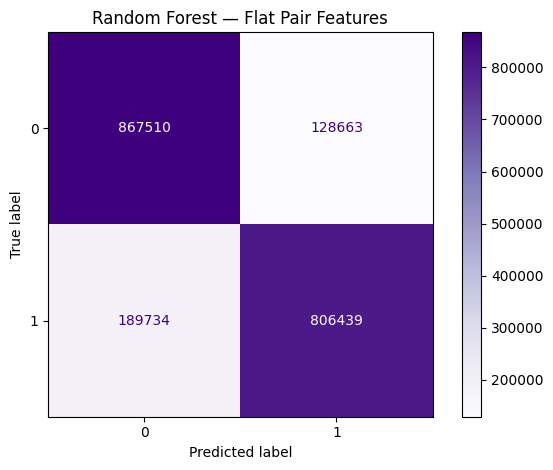

In [8]:
print("\n--- Random Forest (Flat Features) — Test Split ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, rf_flat_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, rf_flat_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, rf_flat_probs):.4f}")
print(f"Train time: {rf_flat_train_time:.1f}s")
print("\nClassification report:")
print(classification_report(y_test_xgb, rf_flat_preds, digits=4))



cm_rf_flat = confusion_matrix(y_test_xgb, rf_flat_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_rf_flat).plot(cmap="Purples")
plt.title("Random Forest — Flat Pair Features")
plt.tight_layout()
plt.show()

In [ ]:
## --- IT TAKES 80 MINUTES, RUN IT ONLY AT THE END --- (we need check to see whether it is necessary or not)


# print("\nPermutation importance (top 15) — sampled to avoid kernel crashes")

# # Use a much smaller held-out sample for permutation importance.
# # Full X_test_xgb is too large and can kill the kernel on this machine.
# rng = np.random.default_rng(42)
# perm_sample_size = min(5000, len(X_test_xgb))
# perm_idx = rng.choice(len(X_test_xgb), size=perm_sample_size, replace=False)
# X_perm = X_test_xgb[perm_idx]
# y_perm = y_test_xgb[perm_idx]

# perm_flat = permutation_importance(
#     rf_flat_model,
#     X_perm,
#     y_perm,
#     n_repeats=3,
#     random_state=42,
#     n_jobs=1,
# )
# rf_flat_importance_df = pd.DataFrame(
#     {
#         "feature": feature_names_xgb,
#         "importance_mean": perm_flat.importances_mean,
#         "importance_std": perm_flat.importances_std,
#     }
# ).sort_values("importance_mean", ascending=False)

# display(rf_flat_importance_df.head(15))

## Pair-Level for Citation Link Prediction

Below, the notebook builds pair-level features from what is already in the dataset: authors, keywords, titles, abstracts, venue, year, and reference lists.

Up to this point, our Exploratory Data Analysis (EDA) focused on **Node-Level Features**—metrics describing individual papers (e.g., `impact_score`, `citation_per_year`, `venue_tier`). While these are excellent for understanding global trends, our ultimate machine learning goal is **Link Prediction**: determining whether Paper A cites Paper B.

To predict links, we cannot look at papers in isolation. We must evaluate the *relationship* between them. 

If we try to predict a citation by feeding the model Paper B's total `impact_score` or `n_citation`, the model will suffer from **Target Leakage**. It would simply learn to predict that "highly cited papers get cited," effectively using future knowledge (citations accumulated up to 2024) to predict a past event. 

Instead, we force the model to rely purely on information available at the exact moment of publication. We do this by calculating **Pair-Level Features**:
1. **Jaccard Similarities:** We measure the mathematical overlap between the two papers' metadata (Authors, Keywords, References, Titles, and Abstracts). A higher Jaccard index implies stronger topical or social proximity.
2. **Temporal Features:** We calculate `year_gap` to understand the age difference between the citing and cited paper, and boolean flags like `same_decade` to capture chronological clustering.
3. **Venue & Overlap Flags:** Simple binary indicators (e.g., `same_venue`, `author_overlap_any`) to capture direct matches.

By constructing a balanced dataset of 10,000 pairs (50% actual citations, 50% random non-citations), we frame the link prediction task as a binary classification problem based purely on relational similarity.

# MODEL 3 -> Random Forest, using pair-level features

In [ ]:
# %pip install -q scikit-learn shap

In [ ]:
import re
import random
from bisect import bisect_right

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

random.seed(42)
np.random.seed(42)


### 2-Phase Unified Dataset
**Change:** Instead of querying random pairs from DuckDB, we now map `build_pair_features` directly onto the Hard Negatives you built in Cell 97.
**Why:** This mathematically guarantees that Phase 1 (Flat Features) and Phase 2 (Pair Features) train and test on the exact same pairs. We subsample 5k pairs to prevent memory crashes.

In [ ]:
print(f"Pair table ready: {len(pair_df):,} rows")
display(pair_df.head())

## The Tabular Supervised Baseline (Random Forest)

### The Objective
Before deploying a complex, graph-native approach (like a Graph Convolutional Network), it is best practice to establish a robust **Supervised Tabular Baseline**. We use a Random Forest Classifier for this task because it handles non-linear relationships well, is robust to outliers in our text similarities, and provides excellent interpretability without requiring feature scaling.

### Feature Selection
Notice the `feature_cols` list below. **We strictly exclude all individual quality metrics** (`impact_score`, `venue_tier`, `n_citation`). The model is only allowed to see:
* Jaccard similarities (Text, Authors, References)
* Temporal distances (`year_gap`, `same_year`)
* Absolute lengths (Number of authors, abstract length)

This ensures our model genuinely learns *why* citations happen based on content and context, rather than "cheating" by looking at global popularity metrics.

### Model Configuration & Evaluation Strategy
1. **Temporal Splitting:** We reuse the upstream train/val/test pair splits so evaluation stays aligned with the rest of the notebook and does not leak future citation structure.
2. **Hyperparameters:** We configure the Random Forest with `n_estimators=300` for stability, `min_samples_leaf=2` to prevent overfitting on highly specific paper pairs, and `class_weight="balanced_subsample"` to handle bootstrap-level imbalances.
3. **Interpretability:** Beyond standard metrics (ROC-AUC, PR-AUC, F1-Score), we prioritize interpretability. We utilize **Permutation Importance** (and SHAP values, if available) to explicitly rank which pair-level signals drive citation decisions, and we calculate the **Brier Score** to ensure our predicted citation probabilities are well-calibrated.

In [ ]:
pair_feature_rows = [build_pair_features(row.src_id, row.dst_id, int(row.label), row.split) for row in pair_df.itertuples(index=False)]
pair_features_df = pd.DataFrame(pair_feature_rows)

In [ ]:

print(f"Pair rows built: {len(pair_features_df):,}")
display(pair_features_df.head())


### Random Forest Missing Data Compatibility
**Change:** Replaced `.fillna(0)` with `.fillna(-999)`.
**Why:** Scikit-Learn's `RandomForestClassifier` crashes if it encounters `NaN`. Just like above, filling with `-999` allows the trees to isolate missing data into dedicated branches without confusing them with actual `0` values (like zero author overlap).

In [ ]:
feature_cols = [
    "year_gap",
    "src_year",
    "dst_year",
    "same_year",
    "same_decade",
    "source_not_earlier",
    "same_venue",
    "author_overlap",
    "author_overlap_any",
    "author_jaccard",
    "keyword_overlap",
    "keyword_overlap_any",
    "keyword_jaccard",
    "title_jaccard",
    "abstract_jaccard",
    "bibliographic_coupling",
    "bibliographic_coupling_any",
    "reference_jaccard",
    "source_n_authors",
    "dst_n_authors",
    "source_n_keywords",
    "dst_n_keywords",
    "source_n_references",
    "dst_n_references",
    "source_title_len",
    "dst_title_len",
    "source_abstract_len",
    "dst_abstract_len",
]

train_df = pair_features_df[pair_features_df["split"] == "train"].copy()
val_df = pair_features_df[pair_features_df["split"] == "val"].copy()
test_df = pair_features_df[pair_features_df["split"] == "test"].copy()

X_train = train_df[feature_cols].fillna(-999)
y_train = train_df["label"].astype(int)
meta_train = train_df[["src_id", "dst_id"]].copy()

X_val = val_df[feature_cols].fillna(-999)
y_val = val_df["label"].astype(int)
meta_val = val_df[["src_id", "dst_id"]].copy()

X_test = test_df[feature_cols].fillna(-999)
y_test = test_df["label"].astype(int)
meta_test = test_df[["src_id", "dst_id"]].copy()

In [ ]:

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print("\nEvaluation on held-out pairs")
print(f"ROC-AUC:  {roc_auc_score(y_test, probs):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, probs):.4f}")
print(f"Brier:    {brier_score_loss(y_test, probs):.4f}")
print("\nClassification report")
print(classification_report(y_test, preds, digits=4))

In [ ]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Pair-level Random Forest: Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:


tree_probs = np.vstack([tree.predict_proba(X_test)[:, 1] for tree in model.estimators_])
uncertainty_df = pd.DataFrame(
    {
        "probability": probs,
        "prob_std": tree_probs.std(axis=0),
        "entropy": -(probs * np.log2(np.clip(probs, 1e-9, 1.0)) + (1 - probs) * np.log2(np.clip(1 - probs, 1e-9, 1.0))),
        "y_true": y_test.to_numpy(),
    },
    index=X_test.index,
)

In [ ]:


print("\nUncertainty summary")
display(uncertainty_df.describe().T)
print("\nMost uncertain test predictions")
display(
    pd.concat([meta_test, uncertainty_df], axis=1)
      .sort_values("prob_std", ascending=False)
      .head(10)
)

In [ ]:

print("\nFeature importance (permutation)")
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision",
)
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": perm.importances_mean,
        "std": perm.importances_std,
    }
).sort_values("importance", ascending=False)
display(importance_df.head(15))

In [ ]:
if HAS_SHAP:
    print("\nSHAP summary plot")
    shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(shap_sample)
    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        shap_sample,
        feature_names=feature_cols,
        show=True,
    )
else:
    print("\nSHAP is not available in the current environment; permutation importance is shown instead.")

### Why this baseline is a better fit

This section is aligned with the target because each example is explicitly a paper pair. It is also easier to explain:
- SHAP highlights which pair-level signals drive a citation decision,
- uncertainty from the forest shows which predictions are ambiguous,
- the features are interpretable and do not rely on citation-count leakage.

So the narrative is: the GCN is a graph-native approach, but the tabular pair model is the clean supervised baseline for the actual link-classification task.

## TRAINING APPENDIX

The original graph training split code is kept here as an appendix so the modeling notebook contains all training-related material in one place.

# TRAINING

In [ ]:
# import os
# import torch
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from torch_geometric.utils import to_undirected


# REBUILD_SPLITS = False


# SPLIT_DIR   = "splits_gcn"
# NODE_PATH   = f"{SPLIT_DIR}/node_df.parquet"
# EDGE_PATH   = f"{SPLIT_DIR}/edge_df.parquet"
# SCALER_MEAN = f"{SPLIT_DIR}/scaler_mean.npy"
# SCALER_STD  = f"{SPLIT_DIR}/scaler_std.npy"


# num_cols = [
#     'n_authors', 'avg_author_citations', 'max_author_citations',
#     'n_references', 'references_author_ratio', 'citation_richness',
#     'years_since_publication', 'citation_per_year', 'impact_score',
#     'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english'
# ]


# if REBUILD_SPLITS or not os.path.exists(NODE_PATH):
#     os.makedirs(SPLIT_DIR, exist_ok=True)

#     sample_n = 15000

#     # 1. Sample nodes with a fixed seed for reproducibility
#     node_df = con.sql(f"""
#         SELECT id, year,
#                n_authors, avg_author_citations, max_author_citations,
#                n_references, references_author_ratio, citation_richness,
#                years_since_publication, citation_per_year, impact_score,
#                venue_median_citations, venue_volume, is_top_venue, is_english
#         FROM papers_with_features
#         WHERE id IS NOT NULL AND TRIM(id) <> ''
#           AND year IS NOT NULL
#         USING SAMPLE reservoir({sample_n})
#     """).df().reset_index(drop=True)

#     node_df['node_idx'] = node_df.index
#     con.register("sampled_papers", node_df[['id']])

#     # 2. Retrieve edges between sampled papers
#     edge_df = con.sql("""
#         SELECT p.id AS src_id, ref AS dst_id
#         FROM papers p
#         CROSS JOIN UNNEST(p."references") AS t(ref)
#         JOIN sampled_papers sp_src ON p.id  = sp_src.id
#         JOIN sampled_papers sp_dst ON ref   = sp_dst.id
#     """).df().drop_duplicates().reset_index(drop=True)

#     if edge_df.empty:
#         raise RuntimeError("No citations found among the sampled papers.")

#     edge_df = (edge_df
#         .merge(node_df[['id', 'node_idx']], left_on='src_id', right_on='id')
#         .rename(columns={'node_idx': 'src_idx'}).drop(columns=['id'])
#         .merge(node_df[['id', 'node_idx']], left_on='dst_id', right_on='id')
#         .rename(columns={'node_idx': 'dst_idx'}).drop(columns=['id'])
#     )

#     # 3. Temporal split on edges — prevents data leakage
#     edge_df = edge_df.merge(
#         node_df[['node_idx', 'year']].rename(columns={'node_idx': 'src_idx', 'year': 'src_year'}),
#         on='src_idx'
#     )

#     edge_df = edge_df.sort_values('src_year').reset_index(drop=True)
#     n         = len(edge_df)
#     train_end = int(n * 0.70)
#     val_end   = int(n * 0.85)

#     conditions = [
#         edge_df.index < train_end,
#         (edge_df.index >= train_end) & (edge_df.index < val_end),
#     ]
#     edge_df['split'] = np.select(conditions, ['train', 'val'], default='test')

#     print(f"Total edges: {n}")
#     print(edge_df['split'].value_counts().sort_index())
#     print(f"Max year train: {edge_df[edge_df.split=='train']['src_year'].max()}")
#     print(f"Min year val:   {edge_df[edge_df.split=='val']['src_year'].min()}")
#     print(f"Min year test:  {edge_df[edge_df.split=='test']['src_year'].min()}")

#     # 4. Normalisation — fit only on train nodes
#     train_node_ids = set(
#         edge_df[edge_df.split == 'train']['src_idx'].tolist() +
#         edge_df[edge_df.split == 'train']['dst_idx'].tolist()
#     )
#     train_mask = node_df['node_idx'].isin(train_node_ids)

#     features_raw = node_df[num_cols].to_numpy(dtype=float)
#     features_raw = np.nan_to_num(features_raw, nan=0.0, posinf=1e9, neginf=-1e9)

#     scaler = StandardScaler()
#     scaler.fit(features_raw[train_mask])
#     node_df[num_cols] = scaler.transform(features_raw)

#     # 5. Save
#     node_df.to_parquet(NODE_PATH, index=False)
#     edge_df.to_parquet(EDGE_PATH, index=False)
#     np.save(SCALER_MEAN, scaler.mean_)
#     np.save(SCALER_STD,  scaler.scale_)
#     print("Splits saved to", SPLIT_DIR)

# else:
#     print("Existing splits found, loading...")
#     node_df = pd.read_parquet(NODE_PATH)
#     edge_df = pd.read_parquet(EDGE_PATH)
#     print(f"Nodes: {len(node_df)} | Edges: {len(edge_df)}")
#     print(edge_df['split'].value_counts().sort_index())

In [ ]:
# FORSE DA TOGLIERE 

# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# SEED = 42
# N_NODES = 100

# # --- 1. Pick the 100 most-connected papers (in + out degree combined) ---
# edges_arr = edge_df[['src_idx', 'dst_idx']].to_numpy()

# # Count appearances on either end
# all_endpoints = np.concatenate([edges_arr[:, 0], edges_arr[:, 1]])
# unique, counts = np.unique(all_endpoints, return_counts=True)
# order = np.argsort(-counts)  # descending

# selected = set(unique[order[:N_NODES]].tolist())

# # Keep edges whose BOTH endpoints are in the sample
# mask = np.isin(edges_arr[:, 0], list(selected)) & np.isin(edges_arr[:, 1], list(selected))
# sub_edges = edges_arr[mask]

# # --- 2. Build directed graph ---
# G = nx.DiGraph()
# G.add_nodes_from(selected)
# G.add_edges_from(sub_edges.tolist())

# # Drop isolated nodes (no edges to other sampled nodes) so the plot stays clean
# G.remove_nodes_from([n for n in list(G.nodes()) if G.degree(n) == 0])

# print(f"Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} citation links")

# # --- 3. Visual encoding ---
# nodes_list = list(G.nodes())
# if 'year' in node_df.columns:
#     node_years = node_df.set_index('node_idx').loc[nodes_list, 'year'].to_numpy()
# else:
#     node_years = None

# in_deg = np.array([G.in_degree(n) for n in nodes_list])
# node_sizes = 60 + in_deg * 25

# # --- 4. Plot ---
# fig, ax = plt.subplots(figsize=(14, 11))
# pos = nx.spring_layout(G, seed=SEED, k=1.2 / np.sqrt(max(G.number_of_nodes(), 1)), iterations=150)

# nx.draw_networkx_edges(
#     G, pos, ax=ax,
#     edge_color='#999', alpha=0.35, width=0.6,
#     arrows=True, arrowsize=7, arrowstyle='->',
#     connectionstyle='arc3,rad=0.1',
# )

# nodes_drawn = nx.draw_networkx_nodes(
#     G, pos, ax=ax,
#     nodelist=nodes_list,
#     node_size=node_sizes,
#     node_color=node_years if node_years is not None else '#1f77b4',
#     cmap='viridis',
#     edgecolors='white', linewidths=0.8,
#     alpha=0.95,
# )

# # Label only the top 10 most-cited papers
# top_nodes = sorted(nodes_list, key=lambda n: G.in_degree(n), reverse=True)[:10]
# nx.draw_networkx_labels(
#     G, pos, ax=ax,
#     labels={n: str(n) for n in top_nodes},
#     font_size=8,
# )

# if node_years is not None:
#     cbar = plt.colorbar(nodes_drawn, ax=ax, shrink=0.7, pad=0.01)
#     cbar.set_label('Publication year')

# ax.set_title(
#     f"Citation graph — {G.number_of_nodes()} papers, {G.number_of_edges()} links "
#     f"(top-{N_NODES} most-connected)",
#     fontsize=13,
# )
# ax.set_axis_off()
# plt.tight_layout()
# plt.show()